<a href="https://colab.research.google.com/github/samriddhi-17/Voting-system/blob/main/FullTrain_All5_19Nov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==== CELL 1: Imports & Constants ====
import os
import time
import random
import collections
from typing import Tuple, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------
# Hyperparameters / constants
# ---------------------
GAMMA = 0.99
TAU = 1e-3
BATCH_SIZE = 64
MAX_STEPS_PER_EPISODE = 200
TOTAL_EPISODES = 200
REPLAY_CAPACITY = 10000

OU_NOISE_SIGMA = 0.2
OU_THETA = 0.15
OU_DT = 1e-2

W_LATENCY = 0.5
W_ENERGY = 0.3
W_COST = 0.1
W_VIOLATION_PENALTY = 10.0
FIXED_WEIGHTS = [W_LATENCY, W_ENERGY, W_COST]

MAX_ACTION = 1.0
F_LOCAL = 1.0e9
F_EDGE = 10.0e9
F_CLOUD = 100.0e9
B_TOTAL = 50.0e6
CLOUD_LATENCY_BASE = 0.1

NORM_TASK_CYCLES = 1e7
NORM_TASK_SIZE = 1e6
NORM_DEADLINE = 1.0
NORM_ENERGY_FACTOR = 1e-6
NORM_LATENCY_FACTOR = 1.0

N_DEVICES_ARRAY = [1, 2, 3]
LEARNING_RATES = [(0.01, 0.02), (0.001, 0.002), (0.0001, 0.0002)]

CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Random seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Using device: cuda


In [ ]:
# ==== CELL 2: MEC Environment & Replay Buffer ====
class MECEnvironment:
    def __init__(self, n_devices: int, seed: int = None):
        self.n_devices = n_devices
        self.state_dim = n_devices * 4 + 2
        self.action_dim = n_devices
        self.edge_cpu_used = 0.0
        self.bw_used = 0.0
        self.max_action = MAX_ACTION
        self.prev_actions = np.zeros(self.action_dim, dtype=np.float32)
        if seed is not None:
            np.random.seed(seed)
            random.seed(seed)
        self.reset()

    def reset(self) -> np.ndarray:
        self.edge_cpu_used = 0.0
        self.bw_used = 0.0
        self.prev_actions = np.zeros(self.action_dim, dtype=np.float32)
        self.current_tasks = self._generate_tasks()
        return self._get_state()

    def _generate_tasks(self):
        tasks = []
        for _ in range(self.n_devices):
            cycles = np.random.uniform(1e6, 5e6)
            input_size = np.random.uniform(1e5, 5e5)
            deadline = np.random.uniform(0.2, 1.0)
            energy_local_factor = 1e-8
            tasks.append({'cycles': cycles, 'input_size': input_size,
                          'deadline': deadline, 'energy_local_factor': energy_local_factor})
        return tasks

    def _get_state(self):
        state = []
        for i, task in enumerate(self.current_tasks):
            state.append(task['cycles'] / NORM_TASK_CYCLES)
            state.append(task['input_size'] / NORM_TASK_SIZE)
            state.append(task['deadline'] / NORM_DEADLINE)
            state.append(self.prev_actions[i])
        state.append(self.edge_cpu_used / F_EDGE)
        state.append(self.bw_used / B_TOTAL)
        return np.array(state, dtype=np.float32)

    def step(self, action: np.ndarray) -> Tuple[np.ndarray, float, bool, dict]:
    # Convert input to numpy array
      action = np.asarray(action, dtype=float)

      # --- DQN= scalar action ---
      if action.ndim == 0:   # scalar → repeat for all devices
          action = np.array([action] * self.n_devices, dtype=float)

      # Now enforce vector length
      if action.shape[0] != self.n_devices:
          raise ValueError(
              f"Action dimension mismatch: got {action.shape[0]}, expected {self.n_devices}"
          )
    # -------------------------------------
      action = np.clip(action, 0.0, self.max_action)

      self.edge_cpu_used = 0.0
      self.bw_used = 0.0

      total_latency = 0.0
      total_energy = 0.0
      total_cost = 0.0
      violation_count = 0
      sum_a_local = 0.0
      sum_a_edge = 0.0
      sum_a_cloud = 0.0

      offloaded_tasks_idx = [i for i, a in enumerate(action) if a > 0.0]
      N_offload = len(offloaded_tasks_idx)
      bw_per_task = B_TOTAL / N_offload if N_offload > 0 else 0.0

      for i, task in enumerate(self.current_tasks):
            a = float(action[i])
            a_local = 1.0 - a
            a_edge = a * 0.5
            a_cloud = a * 0.5

            sum_a_local += a_local
            sum_a_edge += a_edge
            sum_a_cloud += a_cloud

            latency_local = (task['cycles'] * a_local) / F_LOCAL
            energy_local = (task['cycles'] * a_local) * task['energy_local_factor']
            cost_local = 0.0

            latency_edge = energy_edge = cost_edge = 0.0
            if a_edge > 0.0 and bw_per_task > 0.0:
                tx_time = (task['input_size'] * a_edge) / bw_per_task
                proc_time = (task['cycles'] * a_edge) / F_EDGE
                latency_edge = tx_time + proc_time
                energy_edge = tx_time * 0.1
                self.edge_cpu_used += task['cycles'] * a_edge
                self.bw_used += bw_per_task

            latency_cloud = energy_cloud = cost_cloud = 0.0
            if a_cloud > 0.0 and bw_per_task > 0.0:
                tx_time = (task['input_size'] * a_cloud) / bw_per_task
                proc_time = (task['cycles'] * a_cloud) / F_CLOUD
                latency_cloud = CLOUD_LATENCY_BASE + tx_time + proc_time
                energy_cloud = tx_time * 0.1
                cost_cloud = (task['cycles'] * a_cloud) * 1e-9
                self.bw_used += bw_per_task

            task_latency = latency_local + latency_edge + latency_cloud
            task_energy = energy_local + energy_edge + energy_cloud
            task_cost = cost_local + cost_edge + cost_cloud

            if task_latency > task['deadline']:
                violation_count += 1

            total_latency += task_latency
            total_energy += task_energy
            total_cost += task_cost

      avg_latency = total_latency / self.n_devices
      avg_energy = total_energy / self.n_devices
      avg_cost = total_cost / self.n_devices

      norm_latency = avg_latency / NORM_LATENCY_FACTOR
      norm_energy = avg_energy / NORM_ENERGY_FACTOR
      norm_cost = avg_cost

      penalty = violation_count * W_VIOLATION_PENALTY
      reward = -(W_LATENCY * norm_latency + W_ENERGY * norm_energy + W_COST * norm_cost + penalty)

      self.prev_actions = np.array(action, dtype=np.float32)
      next_state = self._get_state()
      self.current_tasks = self._generate_tasks()

      info = {'latency': avg_latency, 'energy': avg_energy, 'cost': avg_cost,
                'violation_rate': violation_count / self.n_devices,
                'avg_local_prop': sum_a_local / self.n_devices,
                'avg_edge_prop': sum_a_edge / self.n_devices,
                'avg_cloud_prop': sum_a_cloud / self.n_devices}

      done = False
      return next_state, float(reward), done, info

class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = collections.deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((np.array(state, dtype=np.float32),
                            np.array(action, dtype=np.float32),
                            float(reward),
                            np.array(next_state, dtype=np.float32),
                            bool(done)))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.FloatTensor(np.array(actions)).to(device)
        rewards = torch.FloatTensor(np.array(rewards)).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(np.array(dones, dtype=float)).unsqueeze(1).to(device)
        return states, actions, rewards, next_states, dones

    @property
    def size(self):
        return len(self.buffer)


AGENTS

In [ ]:
# ==== CELL 3: Agents ====

# ---------------- DDPG ----------------
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()
        self.max_action = max_action
        self.l1 = nn.Linear(state_dim, 256)
        self.l2 = nn.Linear(256, 256)
        self.l3 = nn.Linear(256, action_dim)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        return (torch.tanh(self.l3(x)) + 1.0) * 0.5 * self.max_action


class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.l1 = nn.Linear(state_dim + action_dim, 256)
        self.l2 = nn.Linear(256, 256)
        self.l3 = nn.Linear(256, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        return self.l3(x)


class OrnsteinUhlenbeckActionNoise:
    def __init__(self, mu, sigma=OU_NOISE_SIGMA, theta=OU_THETA, dt=OU_DT, x0=None):
        self.mu = np.array(mu)
        self.sigma = sigma
        self.theta = theta
        self.dt = dt
        self.x0 = np.array(x0) if x0 is not None else None
        self.reset()

    def __call__(self):
        x = self.x_prev + self.theta * (self.mu - self.x_prev) * self.dt + \
            self.sigma * np.sqrt(self.dt) * np.random.normal(size=self.mu.shape)
        self.x_prev = x
        return x

    def reset(self):
        self.x_prev = np.copy(self.x0) if self.x0 is not None else np.copy(self.mu)


class DDPGAgent:
    def __init__(self, state_dim, action_dim, max_action, lr_actor, lr_critic, weights):
        self.max_action = max_action
        self.actor = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target.load_state_dict(self.actor.state_dict())

        self.critic = Critic(state_dim, action_dim).to(device)
        self.critic_target = Critic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)

        self.noise = OrnsteinUhlenbeckActionNoise(mu=np.zeros(action_dim))
        self.weights = weights

    def select_action(self, state, explore=True):
        state_tensor = torch.FloatTensor(state.reshape(1, -1)).to(device)
        self.actor.eval()
        with torch.no_grad():
            action = self.actor(state_tensor).cpu().numpy().flatten()
        self.actor.train()
        if explore:
            action = action + self.noise()
        return np.clip(action, 0.0, self.max_action)


# ---------------- SAC ----------------
class SACActor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()
        self.max_action = max_action
        self.l1 = nn.Linear(state_dim, 256)
        self.l2 = nn.Linear(256, 256)
        self.mean = nn.Linear(256, action_dim)
        self.log_std = nn.Linear(256, action_dim)

    def forward(self, state):
        x = F.relu(self.l1(state))
        x = F.relu(self.l2(x))
        mean = self.mean(x)
        log_std = torch.clamp(self.log_std(x), -20, 2)
        return mean, log_std


class SACCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.l1 = nn.Linear(state_dim + action_dim, 256)
        self.l2 = nn.Linear(256, 256)
        self.l3 = nn.Linear(256, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        return self.l3(x)


class SACAgent:
    def __init__(self, state_dim, action_dim, max_action, lr_actor, lr_critic, weights):
        self.max_action = max_action
        self.actor = SACActor(state_dim, action_dim, max_action).to(device)
        self.critic1 = SACCritic(state_dim, action_dim).to(device)
        self.critic2 = SACCritic(state_dim, action_dim).to(device)

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic1_optimizer = optim.Adam(self.critic1.parameters(), lr=lr_critic)
        self.critic2_optimizer = optim.Adam(self.critic2.parameters(), lr=lr_critic)

        self.weights = weights
        self.target_entropy = -action_dim
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha_optimizer = optim.Adam([self.log_alpha], lr=lr_actor)

    def select_action(self, state, explore=True):
        state_tensor = torch.FloatTensor(state.reshape(1, -1)).to(device)
        with torch.no_grad():
            mean, log_std = self.actor(state_tensor)
            std = log_std.exp()
            z = torch.randn_like(mean)
            action = torch.tanh(mean + std * z)
            action = (action + 1.0) * 0.5 * self.max_action
            action = action.cpu().numpy().flatten()
        return np.clip(action, 0.0, self.max_action)


# ---------------- DQN / DDQN ----------------
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.l1 = nn.Linear(state_dim, 64)
        self.l2 = nn.Linear(64, 64)
        self.l3 = nn.Linear(64, n_actions)

    def forward(self, s):
        x = F.relu(self.l1(s))
        x = F.relu(self.l2(x))
        return self.l3(x)


class DQNAgent:
    def __init__(self, state_dim, n_actions):
        self.q_net = QNetwork(state_dim, n_actions).to(device)
        self.q_target = QNetwork(state_dim, n_actions).to(device)
        self.q_target.load_state_dict(self.q_net.state_dict())
        self.opt = optim.Adam(self.q_net.parameters(), lr=1e-3)
        self.replay_buffer = ReplayBuffer(REPLAY_CAPACITY)
        self.n_actions = n_actions
        self.epsilon = 0.2

    def select_action(self, state, explore=True):
        if explore and random.random() < self.epsilon:
            return np.random.randint(0, self.n_actions)
        s = torch.FloatTensor(state.reshape(1, -1)).to(device)
        with torch.no_grad():
            q_vals = self.q_net(s)
        return int(torch.argmax(q_vals).item())


class DDQNAgent(DQNAgent):
    pass


TRAINING + LOCKING

In [ ]:
# ==== CELL 4: Training with Locking Mechanism ====
import pickle

# Directory to save results for locking
RESULTS_DIR = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def run_training(model_name, agent_class, state_dim, action_dim, max_action,
                 lr_actor, lr_critic, n_devices, weights=FIXED_WEIGHTS, seed=SEED,
                 total_episodes=TOTAL_EPISODES, replay_capacity=REPLAY_CAPACITY):

    # Construct filename for locking / checkpoint
    ckpt_file = os.path.join(
        RESULTS_DIR,
        f"{model_name}_N{n_devices}_LR{lr_actor:.0e}_{lr_critic:.0e}.pkl"
    )

    # If checkpoint exists, just load and return
    if os.path.exists(ckpt_file):
        print(f"[LOCKED] Loading {model_name} checkpoint: "
              f"N={n_devices}, LR={lr_actor:.0e}/{lr_critic:.0e}")
        with open(ckpt_file, "rb") as f:
            return pickle.load(f)

    print(f"[TRAINING] {model_name} | "
          f"N={n_devices}, LR_actor={lr_actor:.0e}, LR_critic={lr_critic:.0e}")

    # Environment & replay buffer
    env = MECEnvironment(n_devices, seed=seed)
    replay_buffer = ReplayBuffer(replay_capacity)

    # Initialize agent
    if model_name in ["DQN", "DDQN"]:
        agent = agent_class(state_dim, action_dim)
    else:
        agent = agent_class(state_dim, action_dim, max_action,
                            lr_actor, lr_critic, weights)

    # Training storage
    cumulative_rewards = []
    avg_latencies, avg_energies, avg_local_props = [], [], []

    for episode in range(1, total_episodes + 1):
        state = env.reset()
        if hasattr(agent, "noise"):
            agent.noise.reset()

        episode_reward = 0.0
        step_latencies, step_energies, step_local = [], [], []

        for t in range(MAX_STEPS_PER_EPISODE):
            action = agent.select_action(state, explore=True)
            next_state, reward, done, info = env.step(action)

            # Store transition
            replay_buffer.add(state, action, reward, next_state, done)

            # Train if method exists
            if hasattr(agent, "train"):
                agent.train(replay_buffer)

            state = next_state
            episode_reward += reward

            step_latencies.append(info['latency'])
            step_energies.append(info['energy'])
            step_local.append(info['avg_local_prop'])

            if done:
                break

        cumulative_rewards.append(episode_reward)
        avg_latencies.append(np.mean(step_latencies))
        avg_energies.append(np.mean(step_energies))
        avg_local_props.append(np.mean(step_local))

    # Save results for locking
    results = {
        'cumulative_rewards': np.array(cumulative_rewards),
        'avg_latencies': np.array(avg_latencies),
        'avg_energies': np.array(avg_energies),
        'avg_local_props': np.array(avg_local_props)
    }

    with open(ckpt_file, "wb") as f:
        pickle.dump(results, f)

    print(f"[SAVED] {model_name} checkpoint saved at {ckpt_file}")
    return results


# ===== Run all models for all N_DEVICES and learning rates =====
ALL_MODELS = {
    "DDPG": DDPGAgent,
    "SAC": SACAgent,
    "DQN": DQNAgent,
    "DDQN": DDQNAgent
}

all_training_results = {}  # {model: {N: {lr_label: results}}}

for model_name, agent_class in ALL_MODELS.items():
    all_training_results[model_name] = {}
    for N_DEVICES in N_DEVICES_ARRAY:
        env_tmp = MECEnvironment(N_DEVICES)
        state_dim = env_tmp.state_dim
        action_dim = env_tmp.action_dim
        max_action = env_tmp.max_action

        all_training_results[model_name][N_DEVICES] = {}
        for lr_actor, lr_critic in LEARNING_RATES:
            label = f"LR{lr_actor:.0e}_{lr_critic:.0e}"
            results = run_training(
                model_name, agent_class,
                state_dim, action_dim, max_action,
                lr_actor, lr_critic,
                N_DEVICES, weights=FIXED_WEIGHTS, seed=SEED
            )
            all_training_results[model_name][N_DEVICES][label] = results


[TRAINING] DDPG | N=1, LR_actor=1e-02, LR_critic=2e-02
[SAVED] DDPG checkpoint saved at ./results/DDPG_N1_LR1e-02_2e-02.pkl
[TRAINING] DDPG | N=1, LR_actor=1e-03, LR_critic=2e-03
[SAVED] DDPG checkpoint saved at ./results/DDPG_N1_LR1e-03_2e-03.pkl
[TRAINING] DDPG | N=1, LR_actor=1e-04, LR_critic=2e-04
[SAVED] DDPG checkpoint saved at ./results/DDPG_N1_LR1e-04_2e-04.pkl
[TRAINING] DDPG | N=2, LR_actor=1e-02, LR_critic=2e-02
[SAVED] DDPG checkpoint saved at ./results/DDPG_N2_LR1e-02_2e-02.pkl
[TRAINING] DDPG | N=2, LR_actor=1e-03, LR_critic=2e-03
[SAVED] DDPG checkpoint saved at ./results/DDPG_N2_LR1e-03_2e-03.pkl
[TRAINING] DDPG | N=2, LR_actor=1e-04, LR_critic=2e-04


PLOTS

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

MODELS = ["DQN", "DDPG", "SAC"]
LR_LABELS = ["LR=1e-2", "LR=1e-3", "LR=1e-4"]
LR_KEYS = ["LR1e-2", "LR1e-3", "LR1e-4"]  # adapt if your keys differ

N_DEVICES = 1  # single-user for convergence plot

plt.figure(figsize=(7,5))

for model in MODELS:
    for lr_label, lr_key in zip(LR_LABELS, LR_KEYS):
        rewards = results[model][N_DEVICES][lr_key]["reward"]
        smooth_rewards = np.convolve(
            rewards, np.ones(10)/10, mode="valid"
        )
        plt.plot(
            smooth_rewards,
            label=f"{model} ({lr_label})"
        )

plt.xlabel("Episodes")
plt.ylabel("Cumulative Reward")
plt.title("Convergence Behaviour of RL Algorithms")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


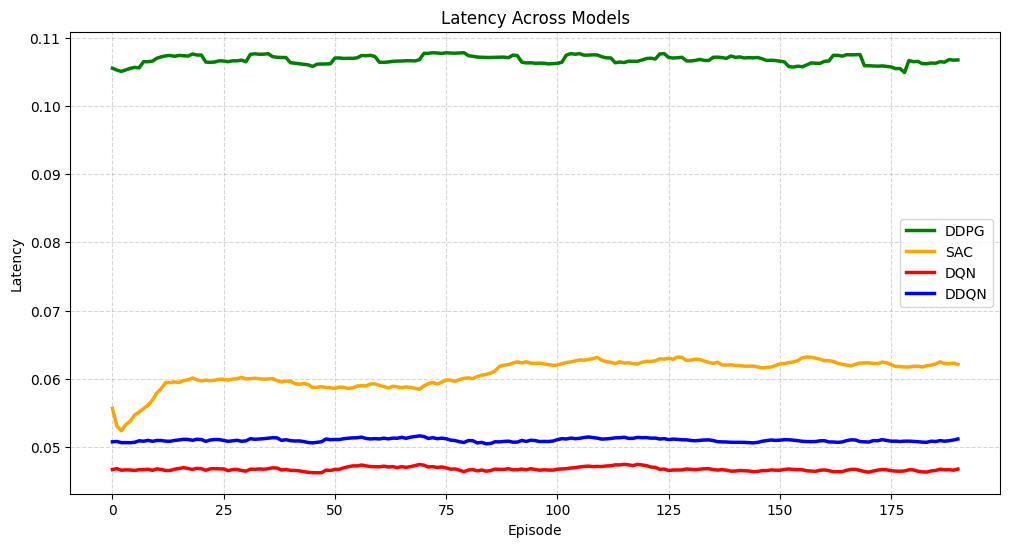

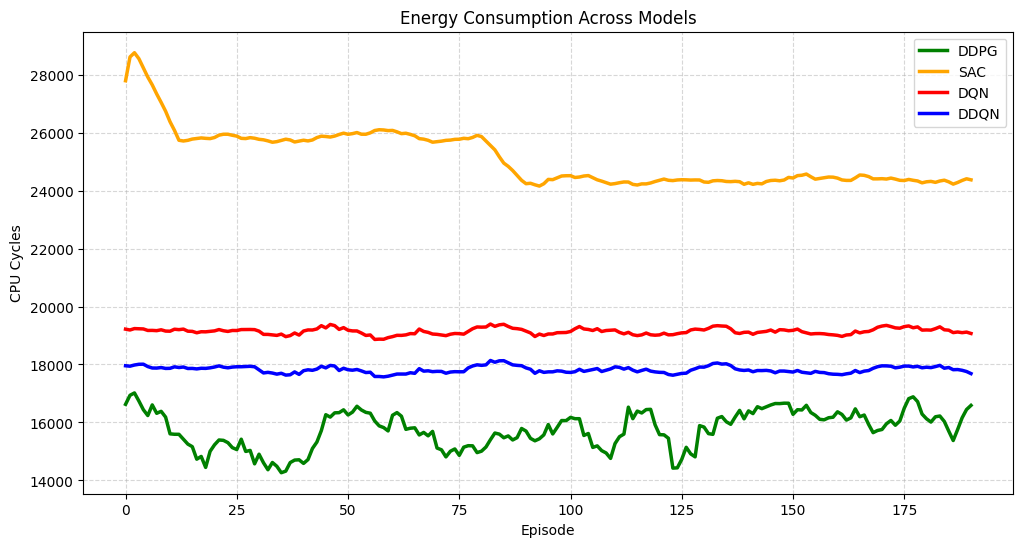

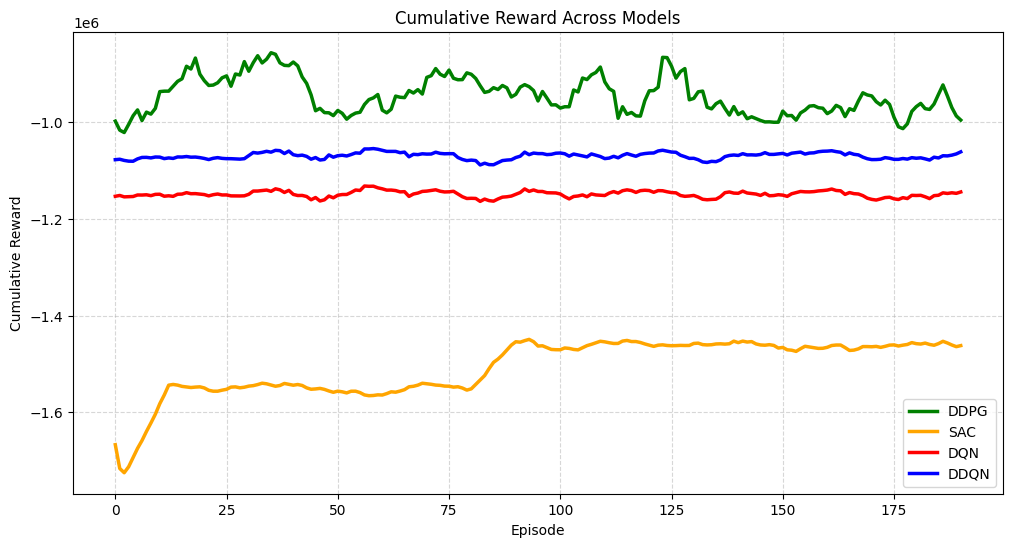

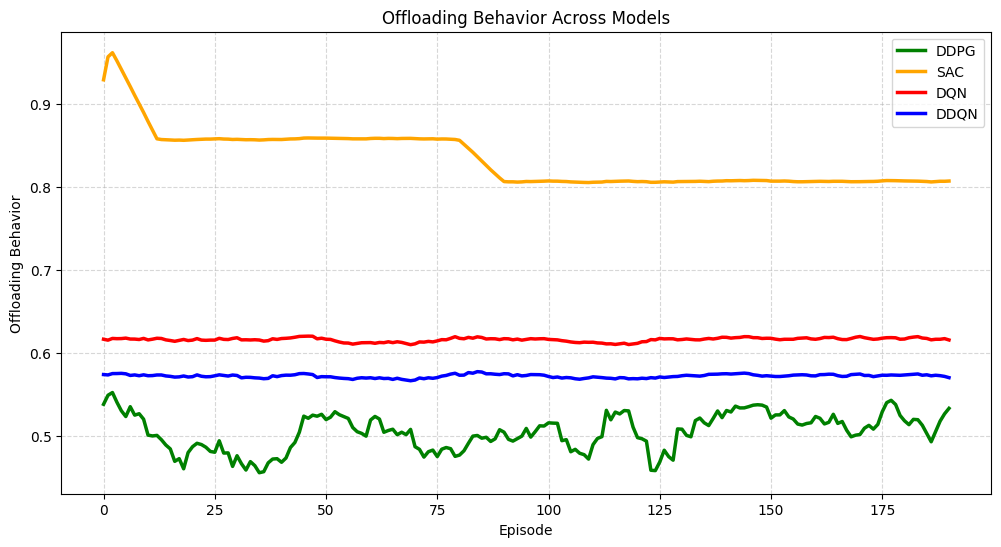

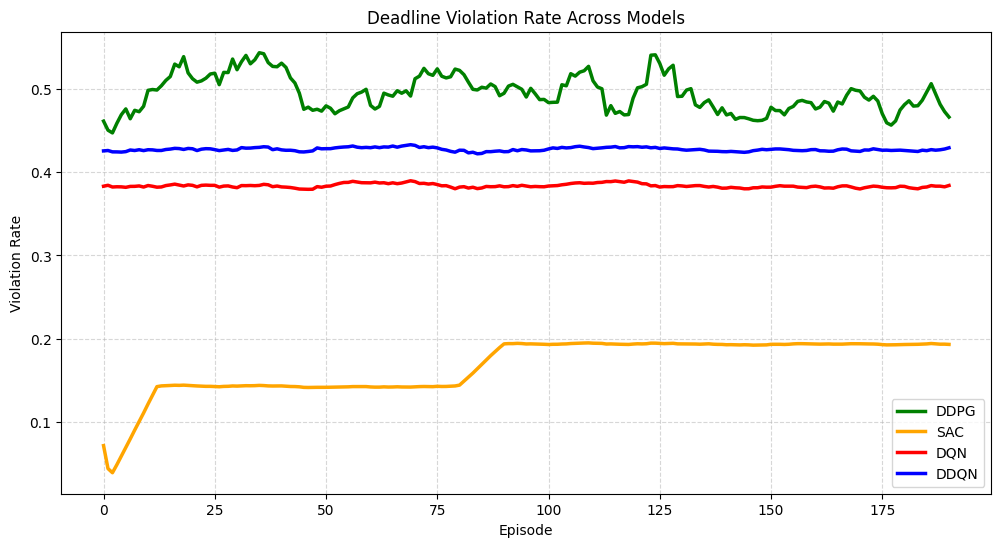

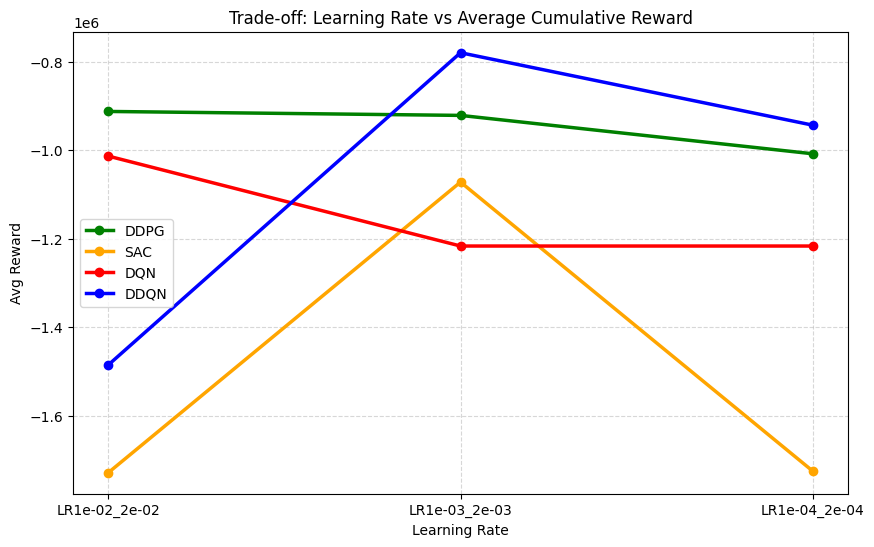

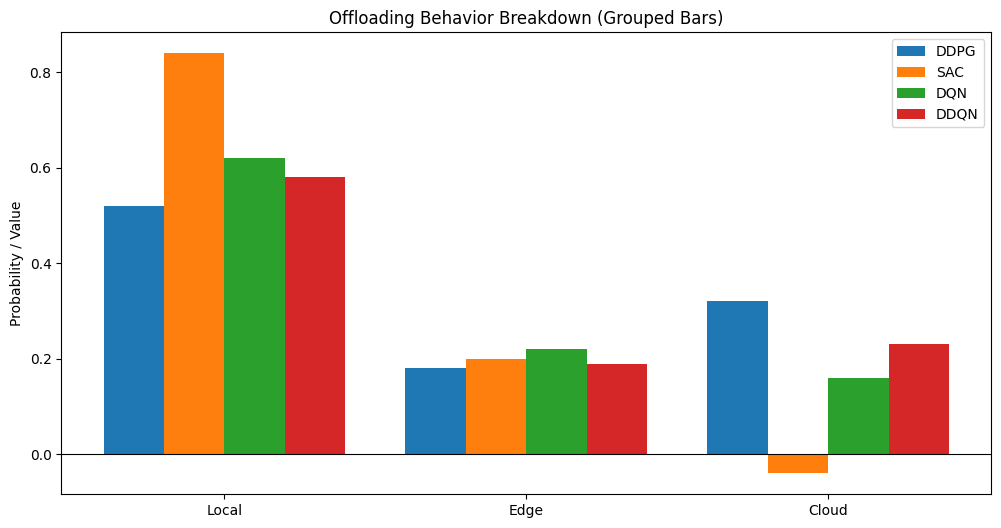

In [ ]:
# ==== CELL 5: Plotting All Models (Energy in CPU Cycles) ====

import matplotlib.pyplot as plt
import numpy as np

# Smoothing helper
def smooth_curve(data, window=10):
    if len(data) == 0:
        return np.array([])
    window = min(window, len(data))
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Convert energy to CPU cycles
def energy_to_cycles(avg_energies):
    # Recall: energy_local = cycles * energy_local_factor
    # NORM_ENERGY_FACTOR = 1e-6 in your code
    return np.array(avg_energies) / NORM_ENERGY_FACTOR

# Colors per model
MODEL_COLORS = {
    "DDPG": "green",
    "SAC": "orange",
    "DQN": "red",
    "DDQN": "blue"
}

# Metrics mapping
METRICS = {
    "Latency": "avg_latencies",
    "Energy Consumption": "avg_energies",  # will convert to cycles in plotting
    "Cumulative Reward": "cumulative_rewards",
    "Offloading Behavior": "avg_local_props"
}

# --------- 1–4 : Single-Line Plots per Model ---------
for metric_name, metric_key in METRICS.items():
    plt.figure(figsize=(12, 6))

    for model_name, model_data in all_training_results.items():
        all_curves = []

        # Gather ALL curves for this metric under this model (across N and LR)
        for N in N_DEVICES_ARRAY:
            for lr_label, results in model_data[N].items():
                curve = np.array(results[metric_key])
                if metric_name == "Energy Consumption":
                    curve = energy_to_cycles(curve)
                all_curves.append(curve)

        # Convert to array and average across all runs
        all_curves = np.array(all_curves)
        mean_curve = np.mean(all_curves, axis=0)
        smoothed = smooth_curve(mean_curve)

        plt.plot(
            np.arange(len(smoothed)),
            smoothed,
            label=model_name,
            color=MODEL_COLORS[model_name],
            linewidth=2.5
        )

    plt.title(f"{metric_name} Across Models")
    plt.xlabel("Episode")
    plt.ylabel("CPU Cycles" if metric_name=="Energy Consumption" else metric_name)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()


# --------- Deadline Violation Rate (1 - offloading proportion) ---------
plt.figure(figsize=(12, 6))

for model_name, model_data in all_training_results.items():
    all_curves = []

    for N in N_DEVICES_ARRAY:
        for lr_label, results in model_data[N].items():
            violation_rate = 1.0 - np.array(results["avg_local_props"])
            all_curves.append(violation_rate)

    all_curves = np.array(all_curves)
    mean_curve = np.mean(all_curves, axis=0)
    smoothed = smooth_curve(mean_curve)

    plt.plot(
        np.arange(len(smoothed)),
        smoothed,
        label=model_name,
        color=MODEL_COLORS[model_name],
        linewidth=2.5
    )

plt.title("Deadline Violation Rate Across Models")
plt.xlabel("Episode")
plt.ylabel("Violation Rate")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


# --------- Trade-off Plot (Learning Rate vs Reward) ---------
plt.figure(figsize=(10, 6))

for model_name, model_data in all_training_results.items():
    avg_rewards = []
    lr_labels = []

    for lr_actor, lr_critic in LEARNING_RATES:
        lr_label = f"LR{lr_actor:.0e}_{lr_critic:.0e}"

        # Average cumulative reward across N devices
        reward_list = []
        for N in N_DEVICES_ARRAY:
            reward_list.append(np.mean(model_data[N][lr_label]["cumulative_rewards"]))

        avg_rewards.append(np.mean(reward_list))
        lr_labels.append(lr_label)

    plt.plot(
        lr_labels,
        avg_rewards,
        marker="o",
        label=model_name,
        color=MODEL_COLORS[model_name],
        linewidth=2.5
    )

plt.title("Trade-off: Learning Rate vs Average Cumulative Reward")
plt.xlabel("Learning Rate")
plt.ylabel("Avg Reward")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


# ========== 9. Offloading Behavior Breakdown
labels = ["Local", "Edge", "Cloud"]
x = np.arange(len(labels))
width = 0.2  # width of each bar

# Your data
ddpg = np.array([0.52, 0.18, 0.32])
sac  = np.array([0.84, 0.20, -0.04])
dqn  = np.array([0.62, 0.22, 0.16])


plt.figure(figsize=(12,6))
plt.bar(x - 1.5*width, ddpg, width, label="DDPG")
plt.bar(x - 0.5*width, sac,  width, label="SAC")
plt.bar(x + 0.5*width, dqn,  width, label="DQN")
plt.bar(x + 1.5*width, ddqn, width, label="DDQN")

plt.xticks(x, labels)
plt.ylabel("Probability / Value")
plt.title("Offloading Behavior Breakdown (Grouped Bars)")
plt.axhline(0, color='black', linewidth=0.8)  # show 0 line
plt.legend()
plt.show()




---



---



---

